# Análise Exploratória dos Dados - parte 3

> **Autor**: Miguel Vieira Machado Pim  
> **Contexto**: Desafio do processo seletivo de estágio IndustriALL

Notebooks anteriores a este:

1. [`01_pre_processing`](01_pre_processing.ipynb)
2. [`02_data_visualization`](02_data_visualization.ipynb)
3. [`03_eda_null_values`](03_eda_null_values.ipynb)
4. [`04_eda_anomaly`](04_eda_anomaly.ipynb)

Este notebook visa fazer uma análise dos sensores do equipamento. Queremos entender se as distribuições dos dados dos sensores nos períodos pré e pós falha mudam consideravelmente.

## Bibliotecas

In [9]:
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.patches import Patch
from scipy.stats import wilcoxon, rankdata
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

## Funções

In [10]:
def preprocess_data(data_path: Path) -> pd.DataFrame:
    """
    Essa função coleta todos os 53 arquivos csv e converte eles em um único dataframe final.

    Args:
        data_path (Path): Caminho para a pasta que contém os arquivos csv.

    Returns:
        pd.DataFrame: Dataframe final contendo todas as features e a coluna target.
    """
    # Coletando todos os arquivos
    feature_dfs = []
    target_df = None

    for file in data_path.glob("*.csv"):
        if "target" in file.name:
            target_df = pd.read_csv(file)
            target_df.columns = ["timestamp", "target"]
        else:
            sensor_id = int(re.search(r"\d+", file.stem).group())
            
            df = pd.read_csv(file)
            df.columns = ["timestamp", f"sensor_{sensor_id}"]

            feature_dfs.append(df)
    
    feature_dfs.sort(
        key=lambda df: int(df.columns[1].split("_")[1])
    )
    
    # Tratando tipos dos datasets
    for df in feature_dfs:
        df["timestamp"] = pd.to_datetime(df["timestamp"])
    
    target_df["target"] = target_df["target"].map({
        "NORMAL": 0,
        "ANORMAL": 1
    }).astype(int)
    target_df["timestamp"] = pd.to_datetime(target_df["timestamp"])
    
    # Construindo dataset final
    df_final = (
        pd.concat(
            [target_df.set_index("timestamp")] +
            [df.set_index("timestamp") for df in feature_dfs],
            axis=1,
            join="outer" # Para mantermos timestamps que não estão em todas as tabelas
        )
        .sort_index()
    )
    
    return df_final

In [11]:
def analisar_correlacoes_spearman(
    df,
    sensores=None,
    target_col="target",
    figsize_matriz=(14, 12),
    figsize_target=(8, 10)
):
    """
    Calcula e plota:

    1. Matriz de correlação de Spearman entre sensores.
    2. Correlação de cada sensor com o target.

    Args:
        df: DataFrame com sensores e target.
        sensores: Lista de sensores. None seleciona todos.
        target_col: Nome da variável target.
        figsize_matriz: Tamanho do heatmap.
        figsize_target: Tamanho do gráfico com o target.

    Returns:
        matriz_correlacao: Matriz completa sensores + target.
        correlacao_target: Correlações ordenadas com o target.
    """
    todos_sensores = sorted(
        [
            coluna for coluna in df.columns
            if re.fullmatch(r"sensor_\d+", coluna)
        ],
        key=lambda coluna: int(coluna.split("_")[1])
    )

    if sensores is None:
        sensores = todos_sensores
    elif isinstance(sensores, str):
        sensores = [sensores]

    colunas = sensores + [target_col]

    matriz_correlacao = (
        df[colunas]
        .corr(method="spearman")
    )

    correlacao_sensores = matriz_correlacao.loc[
        sensores,
        sensores
    ]

    correlacao_target = (
        matriz_correlacao.loc[sensores, target_col]
        .sort_values()
    )

    # Matriz sensor × sensor
    fig, ax = plt.subplots(figsize=figsize_matriz)

    sns.heatmap(
        correlacao_sensores,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        ax=ax,
        cbar_kws={
            "label": "Correlação de Spearman"
        }
    )

    ax.set_title("Correlação de Spearman entre sensores")
    ax.set_xlabel("Sensor")
    ax.set_ylabel("Sensor")

    plt.tight_layout()
    plt.show()

    # Correlação sensor × target
    fig, ax = plt.subplots(figsize=figsize_target)

    correlacao_target.plot.barh(ax=ax)

    ax.axvline(
        0,
        color="black",
        linewidth=0.8
    )

    ax.set_title("Correlação de Spearman dos sensores com o target")
    ax.set_xlabel("Correlação de Spearman")
    ax.set_ylabel("Sensor")
    ax.grid(axis="x", alpha=0.2)

    plt.tight_layout()
    plt.show()

    return matriz_correlacao, correlacao_target

In [12]:
def testar_pre_pos_falhas(
    df,
    minutos_pre=60,
    minutos_pos=60,
    alpha=0.05
):
    dados = df.sort_index()
    sensor_cols = dados.filter(regex=r"^sensor_\d+$").columns.tolist()
    target = dados["target"]

    inicios = dados.index[
        target.eq(1) & target.shift(fill_value=0).eq(0)
    ]

    finais = dados.index[
        target.eq(1) & target.shift(-1, fill_value=0).eq(0)
    ]

    resultados = pd.DataFrame(index=sensor_cols)
    significativos = {sensor: [] for sensor in sensor_cols}

    for numero, (inicio, fim) in enumerate(zip(inicios, finais), start=1):
        nome_falha = f"falha_{numero}"

        pre = dados.loc[
            (dados.index >= inicio - pd.Timedelta(minutes=minutos_pre)) &
            (dados.index < inicio),
            sensor_cols
        ]

        pos = dados.loc[
            (dados.index > fim) &
            (dados.index <= fim + pd.Timedelta(minutes=minutos_pos)),
            sensor_cols
        ]

        for sensor in sensor_cols:
            # Inverte o pré para parear pela distância até a falha
            antes = pre[sensor].iloc[::-1].reset_index(drop=True)
            depois = pos[sensor].reset_index(drop=True)

            n = min(len(antes), len(depois))

            pares = pd.concat(
                [antes.iloc[:n], depois.iloc[:n]],
                axis=1,
                keys=["pre", "pos"]
            ).dropna()

            if len(pares) == 0:
                p_value = np.nan

            elif np.allclose(pares["pre"], pares["pos"]):
                p_value = 1.0

            else:
                p_value = wilcoxon(
                    pares["pre"],
                    pares["pos"],
                    alternative="two-sided"
                ).pvalue

            resultados.loc[sensor, nome_falha] = p_value

            if pd.notna(p_value) and p_value < alpha:
                significativos[sensor].append(nome_falha)

    resultados = resultados.astype(float).round(4)

    display(
        resultados.style
        .format("{:.4f}", na_rep="-")
        .map(
            lambda valor: (
                "background-color: lightcoral; font-weight: bold"
                if pd.notna(valor) and valor < alpha
                else ""
            )
        )
    )

    return resultados, significativos

In [13]:
def _ajuste_bh(p_values):
    p_values = pd.Series(p_values, dtype=float)
    validos = p_values.dropna()

    ordem = np.argsort(validos.values)
    ordenados = validos.values[ordem]
    m = len(ordenados)

    ajustados = ordenados * m / np.arange(1, m + 1)
    ajustados = np.minimum.accumulate(ajustados[::-1])[::-1]
    ajustados = np.clip(ajustados, 0, 1)

    resultado = pd.Series(np.nan, index=p_values.index)
    resultado.loc[validos.index[ordem]] = ajustados

    return resultado


def _efeito_bisserial(diferencas):
    diferencas = np.asarray(diferencas)
    diferencas = diferencas[diferencas != 0]

    if len(diferencas) == 0:
        return 0.0

    postos = rankdata(np.abs(diferencas))

    positivos = postos[diferencas > 0].sum()
    negativos = postos[diferencas < 0].sum()

    return (positivos - negativos) / (positivos + negativos)


def rankear_sensores_por_falha(
    df,
    minutos_pre=60,
    minutos_pos=60,
    alpha=0.05,
    top_n=10
):
    dados = df.sort_index()
    sensores = dados.filter(regex=r"^sensor_\d+$").columns.tolist()
    target = dados["target"]

    inicios = dados.index[target.eq(1) & target.shift(fill_value=0).eq(0)]
    finais = dados.index[target.eq(1) & target.shift(-1, fill_value=0).eq(0)]

    resultados = []

    for numero, (inicio, fim) in enumerate(zip(inicios, finais), start=1):
        falha = f"falha_{numero}"

        pre = dados.loc[
            (dados.index >= inicio - pd.Timedelta(minutes=minutos_pre)) &
            (dados.index < inicio),
            sensores
        ]

        pos = dados.loc[
            (dados.index > fim) &
            (dados.index <= fim + pd.Timedelta(minutes=minutos_pos)),
            sensores
        ]

        for sensor in sensores:
            antes = pre[sensor].iloc[::-1].reset_index(drop=True)
            depois = pos[sensor].reset_index(drop=True)

            n = min(len(antes), len(depois))

            pares = pd.concat(
                [antes.iloc[:n], depois.iloc[:n]],
                axis=1,
                keys=["pre", "pos"]
            ).dropna()

            if len(pares) < 2:
                p_value = np.nan
                efeito = np.nan
                delta = np.nan
            else:
                diferencas = pares["pos"] - pares["pre"]
                delta = diferencas.median()
                efeito = _efeito_bisserial(diferencas)

                p_value = (
                    1.0
                    if np.allclose(diferencas, 0)
                    else wilcoxon(
                        pares["pre"],
                        pares["pos"],
                        alternative="two-sided"
                    ).pvalue
                )

            resultados.append({
                "falha": falha,
                "sensor": sensor,
                "p_value": p_value,
                "efeito": efeito,
                "delta_mediana": delta
            })

    ranking = pd.DataFrame(resultados)

    ranking["p_ajustado"] = ranking.groupby("falha")["p_value"].transform(_ajuste_bh)
    ranking["significativo"] = ranking["p_ajustado"] < alpha

    ranking["score"] = (
        ranking["efeito"].abs()
        * -np.log10(ranking["p_ajustado"].clip(lower=1e-300))
    )

    ranking["direcao"] = np.select(
        [
            ranking["delta_mediana"] > 0,
            ranking["delta_mediana"] < 0
        ],
        ["aumentou", "diminuiu"],
        default="sem mudança"
    )

    ranking["rank"] = (
        ranking.groupby("falha")["score"]
        .rank(ascending=False, method="min")
    )

    ranking = ranking.sort_values(
        ["falha", "significativo", "score"],
        ascending=[True, False, False]
    )

    melhores_por_falha = (
        ranking[ranking["significativo"]]
        .groupby("falha", group_keys=False)
        .head(top_n)
        .groupby("falha")["sensor"]
        .apply(list)
        .to_dict()
    )

    return ranking, melhores_por_falha

In [14]:
def agrupar_falhas_e_rankear(
    ranking_df,
    max_clusters=4,
    top_n=10
):
    base = ranking_df.copy()

    # Preserva intensidade e direção da mudança
    base["score_assinado"] = (
        np.sign(base["efeito"]) * base["score"]
    )

    matriz = (
        base.pivot(
            index="falha",
            columns="sensor",
            values="score_assinado"
        )
        .fillna(0)
    )

    # Clustering hierárquico
    distancias = pdist(matriz, metric="cosine")
    linkage_matrix = linkage(distancias, method="average")

    # Escolhe número de grupos pelo silhouette
    avaliacoes = []

    limite = min(max_clusters, len(matriz) - 1)

    for k in range(2, limite + 1):
        labels = fcluster(
            linkage_matrix,
            t=k,
            criterion="maxclust"
        )

        score_silhouette = silhouette_score(
            matriz,
            labels,
            metric="cosine"
        )

        avaliacoes.append({
            "n_grupos": k,
            "silhouette": score_silhouette
        })

    avaliacao_clusters = pd.DataFrame(avaliacoes)

    melhor_k = int(
        avaliacao_clusters.loc[
            avaliacao_clusters["silhouette"].idxmax(),
            "n_grupos"
        ]
    )

    labels = fcluster(
        linkage_matrix,
        t=melhor_k,
        criterion="maxclust"
    )

    grupos_falhas = pd.Series(
        labels,
        index=matriz.index,
        name="tipo_falha"
    )

    base["tipo_falha"] = base["falha"].map(grupos_falhas)

    # Similaridade entre falhas
    similaridade = pd.DataFrame(
        cosine_similarity(matriz),
        index=matriz.index,
        columns=matriz.index
    )

    def resumir_sensor(grupo):
        significativos = grupo[grupo["significativo"]]

        total_falhas = grupo["falha"].nunique()
        n_significativas = significativos["falha"].nunique()

        frequencia = n_significativas / total_falhas

        if len(significativos):
            sinais = np.sign(significativos["efeito"])
            consistencia = abs(sinais.mean())

            media_efeito = significativos["efeito"].mean()

            direcao = (
                "aumentou"
                if media_efeito > 0
                else "diminuiu"
                if media_efeito < 0
                else "mista"
            )
        else:
            consistencia = 0
            direcao = "não significativo"

        score_medio = grupo["score"].mean()

        return pd.Series({
            "falhas_no_grupo": total_falhas,
            "falhas_significativas": n_significativas,
            "frequencia_significativa": frequencia,
            "efeito_medio_abs": grupo["efeito"].abs().mean(),
            "score_medio": score_medio,
            "consistencia_direcao": consistencia,
            "direcao_predominante": direcao,
            "score_ranking": (
                score_medio
                * frequencia
                * (0.5 + 0.5 * consistencia)
            )
        })

    # Ranking por tipo de falha
    ranking_grupos = (
        base.groupby(["tipo_falha", "sensor"])
        .apply(resumir_sensor)
        .reset_index()
        .sort_values(
            ["tipo_falha", "score_ranking"],
            ascending=[True, False]
        )
    )

    ranking_por_tipo = {
        tipo: grupo.head(top_n).reset_index(drop=True)
        for tipo, grupo in ranking_grupos.groupby("tipo_falha")
    }

    # Similaridade
    fig, ax = plt.subplots(figsize=(8, 6))

    sns.heatmap(
        similaridade,
        annot=True,
        fmt=".2f",
        center=0,
        cmap="coolwarm",
        ax=ax
    )

    ax.set_title("Similaridade entre falhas")
    plt.tight_layout()
    plt.show()

    # Dendrograma
    fig, ax = plt.subplots(figsize=(10, 5))

    dendrogram(
        linkage_matrix,
        labels=matriz.index,
        ax=ax
    )

    ax.set_title(f"Agrupamento das falhas — {melhor_k} grupos")
    ax.set_ylabel("Distância")
    plt.tight_layout()
    plt.show()

    print("Grupos encontrados:")

    for tipo, falhas in grupos_falhas.groupby(grupos_falhas):
        print(f"Tipo {tipo}: {', '.join(falhas.index)}")

    for tipo, ranking in ranking_por_tipo.items():
        print(f"\nSensores mais relevantes — Tipo {tipo}")

        display(
            ranking.style.format({
                "frequencia_significativa": "{:.1%}",
                "efeito_medio_abs": "{:.3f}",
                "score_medio": "{:.3f}",
                "consistencia_direcao": "{:.2f}",
                "score_ranking": "{:.3f}"
            })
        )

    return {
        "grupos_falhas": grupos_falhas,
        "similaridade": similaridade,
        "avaliacao_clusters": avaliacao_clusters,
        "ranking_por_tipo": ranking_por_tipo,
    }

In [15]:
def plotar_boxplots_todas_falhas(
    df,
    minutos=60,
    sensores_por_linha=5
):
    sensor_cols = [
        f"sensor_{i}"
        for i in range(52)
        if f"sensor_{i}" in df.columns
    ]

    target = df["target"]

    inicios = df.index[
        target.eq(1) & target.shift(fill_value=0).eq(0)
    ]

    finais = df.index[
        target.eq(1) & target.shift(-1, fill_value=0).eq(0)
    ]

    falhas = list(zip(inicios, finais))

    janelas = []

    for inicio, fim in falhas:
        pre = df.loc[
            (df.index >= inicio - pd.Timedelta(minutes=minutos)) &
            (df.index < inicio),
            sensor_cols
        ]

        pos = df.loc[
            (df.index > fim) &
            (df.index <= fim + pd.Timedelta(minutes=minutos)),
            sensor_cols
        ]

        janelas.append((pre, pos))

    n_colunas = sensores_por_linha
    n_linhas = math.ceil(len(sensor_cols) / n_colunas)

    fig, axes = plt.subplots(
        n_linhas,
        n_colunas,
        figsize=(5 * n_colunas, 4 * n_linhas),
        sharex=False,
        sharey=False
    )

    axes = np.atleast_1d(axes).ravel()

    posicoes = []
    rotulos = []

    for i in range(len(falhas)):
        base = i * 3 + 1

        posicoes.extend([base, base + 1])
        rotulos.extend([
            f"F{i + 1}\nPré",
            f"F{i + 1}\nPós"
        ])

    for ax, sensor in zip(axes, sensor_cols):
        for i, (pre, pos) in enumerate(janelas):
            pos_pre = i * 3 + 1
            pos_pos = pos_pre + 1

            antes = pre[sensor].dropna().values
            depois = pos[sensor].dropna().values

            if len(antes):
                ax.boxplot(
                    [antes],
                    positions=[pos_pre],
                    widths=0.75,
                    showfliers=False,
                    patch_artist=True,
                    boxprops={"facecolor": "tab:blue", "alpha": 0.7},
                    medianprops={"color": "black"}
                )

            if len(depois):
                ax.boxplot(
                    [depois],
                    positions=[pos_pos],
                    widths=0.75,
                    showfliers=False,
                    patch_artist=True,
                    boxprops={"facecolor": "tab:orange", "alpha": 0.7},
                    medianprops={"color": "black"}
                )

        ax.set_xticks(posicoes)
        ax.set_xticklabels(rotulos, fontsize=8)
        ax.set_title(sensor)
        ax.set_ylabel("Valor")
        ax.grid(axis="y", alpha=0.2)

    for ax in axes[len(sensor_cols):]:
        ax.axis("off")

    fig.legend(
        handles=[
            Patch(facecolor="tab:blue", alpha=0.7, label="Pré-falha"),
            Patch(facecolor="tab:orange", alpha=0.7, label="Pós-falha")
        ],
        loc="upper center",
        ncol=2
    )

    fig.suptitle(
        f"{minutos} minutos antes e depois de todas as falhas",
        y=0.995
    )

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

## Carregando os dados

In [16]:
data_path = Path("../data")

industry_df = preprocess_data(data_path)

In [17]:
eda_df = industry_df.copy()
eda_df

,target,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,...,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-04-01 00:00:00,0,4.548754,90.886874,58.698896,89.301134,1011.733181,97.284889,33.248746,-10.390227,29.262578,...,101.547023,154.291476,114.466107,103.082616,119.246973,60.729332,310.022461,124.735196,426.651658,410.820484
2018-04-01 00:01:00,0,7.887998,56.555373,80.802810,120.898222,1358.466600,202.583688,32.494870,19.427739,61.038519,...,71.846296,59.239207,90.076161,93.760055,63.457947,62.910653,306.084796,158.822485,375.316113,143.620728
2018-04-01 00:02:00,0,4.975919,182.086958,87.273632,9.914782,1056.489015,147.098428,36.402837,38.900027,30.304666,...,59.174616,87.136301,99.274584,111.916792,60.560834,81.332910,353.863854,88.772027,444.809188,618.898000
2018-04-01 00:03:00,0,6.304142,58.417235,75.059520,64.167463,1619.924847,307.722320,34.283344,46.602862,44.859311,...,0.674927,110.321579,103.978381,103.705604,24.141894,36.219671,301.563110,53.387484,414.052496,427.323378
2018-04-01 00:04:00,0,1.671733,108.946809,94.910470,14.551922,591.648283,-7.684779,30.980682,39.293311,1.229287,...,71.785623,112.435498,103.170425,110.566095,53.913605,116.770552,298.957820,168.746952,431.548430,514.659884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-31 23:55:00,0,6.066461,128.157145,144.452803,66.621842,1791.181163,172.833101,13.116142,52.438915,32.694638,...,77.001917,105.953758,169.203415,74.959180,159.206995,98.736928,432.326663,199.902569,NaN,343.198701
2018-08-31 23:56:00,0,4.057784,-31.186502,49.775117,69.397205,1166.424000,146.161645,26.785100,17.436183,39.612008,...,32.268873,12.201309,59.127149,149.304241,26.936970,125.800942,402.294815,218.904951,NaN,381.082811
2018-08-31 23:57:00,0,6.751912,80.433446,107.038506,137.923928,1060.918628,106.901675,37.495990,20.406074,33.073722,...,87.497962,90.664739,144.615688,29.140853,118.974814,75.747273,269.339456,260.899365,NaN,452.482461


## Levantando a hipótese

Vamos levantar a nossa primeira hipótese acerca dos dados:

- **HIPÓTESE**: A distribuição dos dados antes e depois da falha é diferente.

> Se as distribuições possuírem diferença estatística para um sensor específico, então, este sensor explica, em um certo nível, aquela falha na máquina.


Para isso, iremos definir nossas hipóteses $H_0$ e $H_1$, e iremos utilizar o teste de Wilcoxon para comparar as duas distribuições.

- $H_0$ (hipótese nula): a distribuição dos valores do sensor nos períodos pré-falha e pós-falha é a mesma.
- $H_1$ (hipótese alternativa): a distribuição dos valores do sensor nos períodos pré-falha e pós-falha é diferente.

### Análise de 1 hora

In [18]:
PERIODO_ANALISE = 60 # Analisando 1 hora antes e depois das falhas

In [19]:
p_values_df, falhas_significativas = testar_pre_pos_falhas(
    eda_df,
    minutos_pre=PERIODO_ANALISE,
    minutos_pos=PERIODO_ANALISE
)

,falha_1,falha_2,falha_3,falha_4,falha_5,falha_6,falha_7
sensor_0,0.0032,0.0000,0.0000,0.0000,0.9179,0.0000,0.0904
sensor_1,0.2245,0.2925,0.2389,0.2448,0.1221,0.1901,0.3972
sensor_2,0.5559,0.0060,0.2108,0.3275,0.9355,0.0646,0.4982
sensor_3,0.4395,0.7628,0.6219,0.3810,0.9179,0.4936,0.3460
sensor_4,0.0001,0.0002,0.1450,0.0000,0.2858,0.0000,0.0000
sensor_5,0.0000,0.0002,0.0000,0.0164,0.9004,0.7128,0.0007
sensor_6,0.2302,0.0007,0.0106,0.0181,0.3460,0.3167,0.0212
sensor_7,0.6271,0.5124,0.0041,0.1532,0.7572,0.8655,0.0836
sensor_8,0.8024,0.2569,0.0164,0.4982,0.0823,0.7684,0.7740
sensor_9,0.6428,0.0904,0.4439,0.0636,0.9004,0.7349,0.0877


Para que possamos visualizar melhor como cada sensor influencia em cada falha, será computado um score para cada um dos sensores.

In [20]:
ranking_df, melhores_sensores = rankear_sensores_por_falha(
    eda_df,
    minutos_pre=PERIODO_ANALISE,
    minutos_pos=PERIODO_ANALISE,
    top_n=10
)

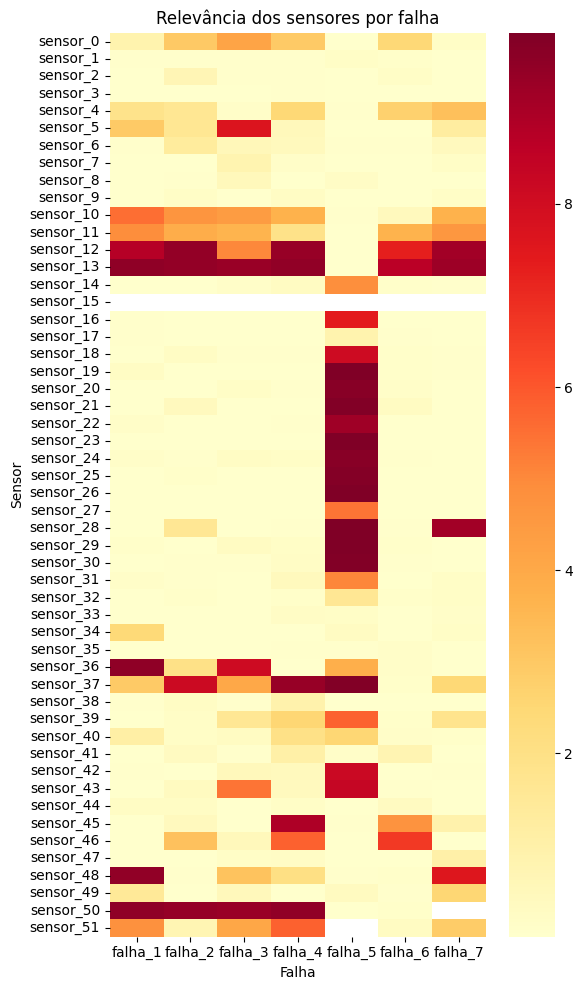

In [21]:
matriz_score = ranking_df.pivot(
    index="sensor",
    columns="falha",
    values="score"
)

ordem_sensores = sorted(
    matriz_score.index,
    key=lambda sensor: int(sensor.split("_")[1])
)

ordem_falhas = sorted(
    matriz_score.columns,
    key=lambda falha: int(falha.split("_")[1])
)

matriz_score = matriz_score.loc[
    ordem_sensores,
    ordem_falhas
]

fig, ax = plt.subplots(figsize=(6, 10))

sns.heatmap(
    matriz_score,
    cmap="YlOrRd",
    ax=ax
)

ax.set_title("Relevância dos sensores por falha")
ax.set_xlabel("Falha")
ax.set_ylabel("Sensor")

plt.tight_layout()
plt.show()

Esse *heatmap* nos auxilia a visualizar a relação entre a influência dos sensores em cada uma das falhas do equipamento.

A **falha_5** parece ter tido uma causa muito diferente das demais falhas. Por isso, vamos fazer uma análise das falhas da seguinte maneira:
- Calcular a distância entre cada uma das falhas utilizando similaridade de cossênos.
- Realizar o agrupamento das falhas para obter a melhor divisão de grupos pelo coeficiente de silhueta.

/tmp/ipykernel_11913/2393656317.py:124: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(resumir_sensor)


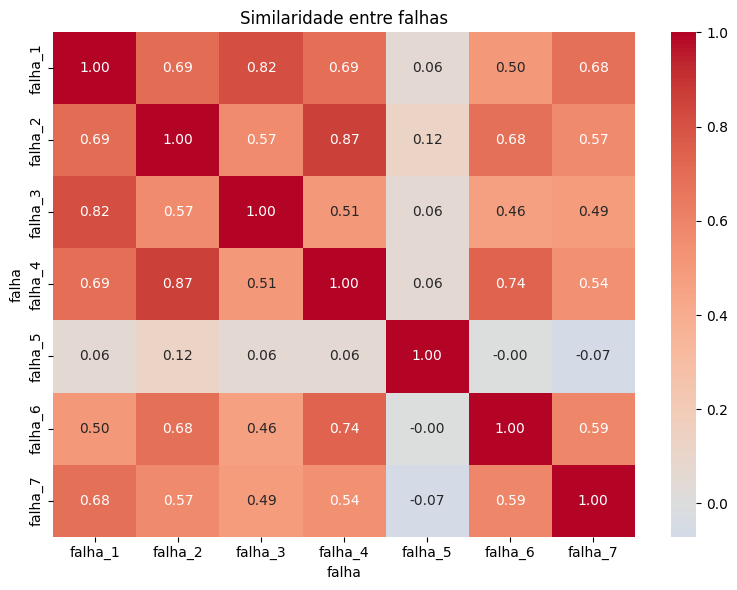

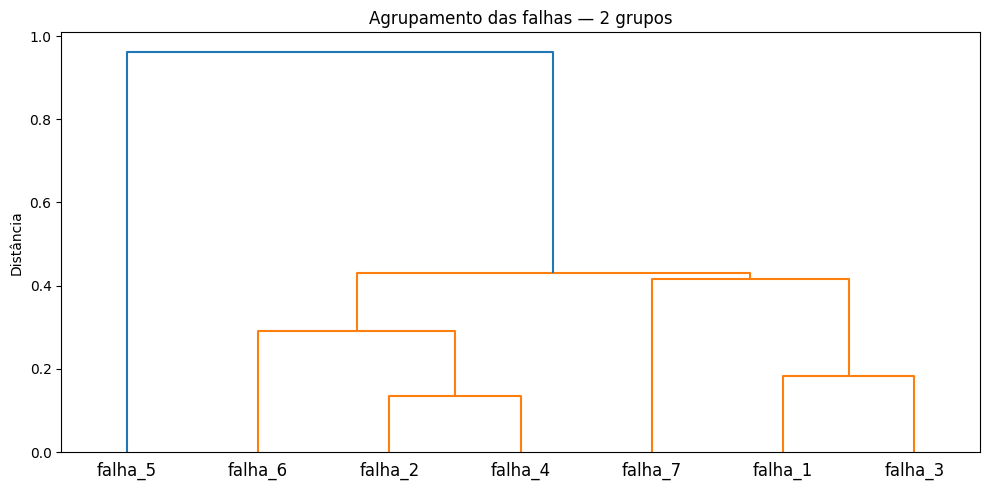

Grupos encontrados:
Tipo 1: falha_1, falha_2, falha_3, falha_4, falha_6, falha_7
Tipo 2: falha_5

Sensores mais relevantes — Tipo 1


,tipo_falha,sensor,falhas_no_grupo,falhas_significativas,frequencia_significativa,efeito_medio_abs,score_medio,consistencia_direcao,direcao_predominante,score_ranking
0,1,sensor_13,6,6,100.0%,0.997,9.301,1.00,diminuiu,9.301
1,1,sensor_12,6,6,100.0%,0.944,8.182,1.00,diminuiu,8.182
2,1,sensor_50,6,4,66.7%,0.838,7.579,1.00,diminuiu,5.053
3,1,sensor_11,6,6,100.0%,0.721,3.771,1.00,diminuiu,3.771
4,1,sensor_10,6,5,83.3%,0.702,3.754,1.00,diminuiu,3.128
5,1,sensor_37,6,5,83.3%,0.699,4.522,0.60,aumentou,3.015
6,1,sensor_51,6,5,83.3%,0.628,3.090,1.00,diminuiu,2.575
7,1,sensor_48,6,4,66.7%,0.589,3.743,1.00,diminuiu,2.496
8,1,sensor_5,6,5,83.3%,0.509,2.330,1.00,diminuiu,1.942
9,1,sensor_0,6,5,83.3%,0.570,2.268,1.00,diminuiu,1.890



Sensores mais relevantes — Tipo 2


,tipo_falha,sensor,falhas_no_grupo,falhas_significativas,frequencia_significativa,efeito_medio_abs,score_medio,consistencia_direcao,direcao_predominante,score_ranking
0,2,sensor_19,1,1,100.0%,1.000,9.868,1.00,aumentou,9.868
1,2,sensor_28,1,1,100.0%,1.000,9.868,1.00,aumentou,9.868
2,2,sensor_29,1,1,100.0%,1.000,9.868,1.00,aumentou,9.868
3,2,sensor_23,1,1,100.0%,0.999,9.857,1.00,aumentou,9.857
4,2,sensor_26,1,1,100.0%,0.997,9.836,1.00,aumentou,9.836
5,2,sensor_21,1,1,100.0%,0.993,9.803,1.00,aumentou,9.803
6,2,sensor_37,1,1,100.0%,0.993,9.803,1.00,aumentou,9.803
7,2,sensor_30,1,1,100.0%,0.992,9.793,1.00,aumentou,9.793
8,2,sensor_25,1,1,100.0%,0.991,9.782,1.00,aumentou,9.782
9,2,sensor_20,1,1,100.0%,0.986,9.707,1.00,aumentou,9.707


In [22]:
analise_falhas = agrupar_falhas_e_rankear(
    ranking_df,
    max_clusters=4,
    top_n=10
)

Concluimos que, claramente a **falha 5** teve alguma causa diferente das demais causas.

Para finalizar a análise, vamos plotar os *boxplots* para ter uma visualização da distribuição de dados de cada sensor, em cada falha. Com isso, será possível analisar com mais cuidado se os resultados encontrados realmente refletem na parte visual do *boxplot*.

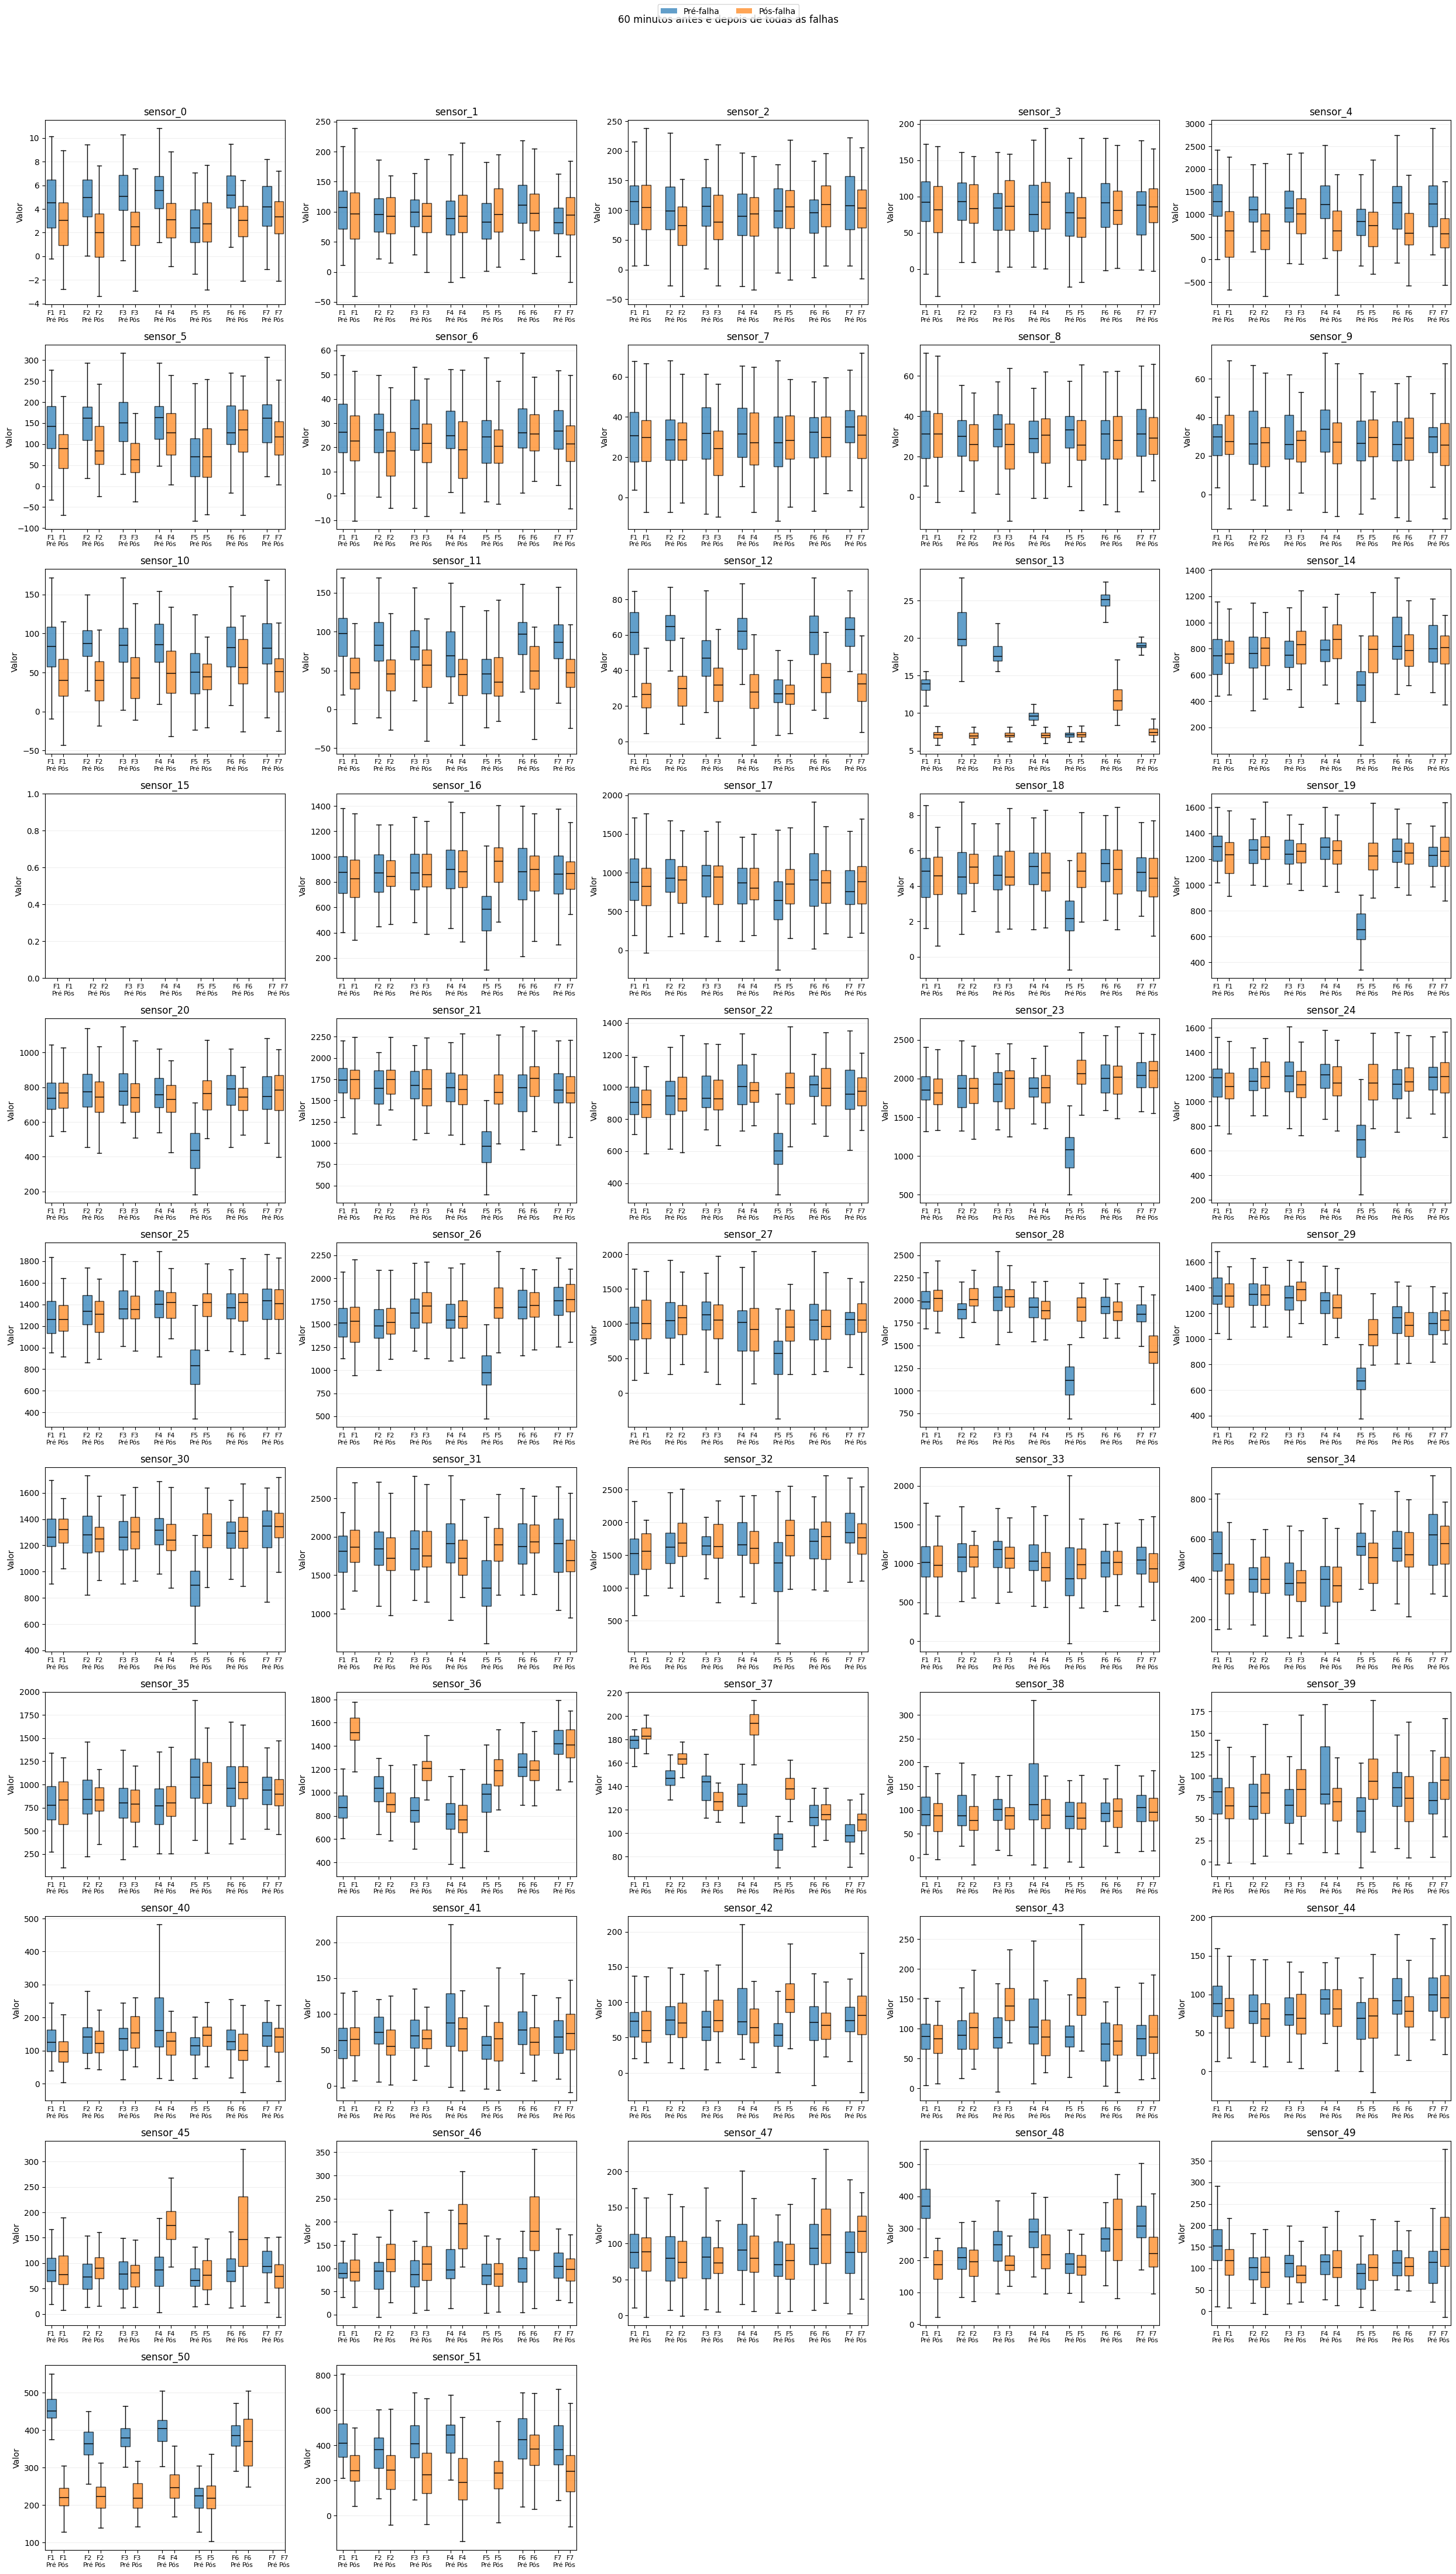

In [23]:
plotar_boxplots_todas_falhas(
    eda_df,
    minutos=PERIODO_ANALISE,
)

Terminamos essa análise com um ranking de top sensores:

<center>

| Ranking | Top sensores tipo de falha 1 | Top sensores tipo de falha 2 |
| ------: | ---------------------------- | ---------------------------- |
|       1 | `sensor_13`                  | `sensor_19`                  |
|       2 | `sensor_12`                  | `sensor_28`                  |
|       3 | `sensor_50`                  | `sensor_29`                  |
|       4 | `sensor_11`                  | `sensor_23`                  |
|       5 | `sensor_10`                  | `sensor_26`                  |
|       6 | `sensor_37`                  | `sensor_21`                  |
|       7 | `sensor_51`                  | `sensor_37`                  |
|       8 | `sensor_48`                  | `sensor_30`                  |
|       9 | `sensor_5`                   | `sensor_25`                  |
|      10 | `sensor_0`                   | `sensor_20`                  |
<center/>


### Análise de 1 dia

In [24]:
PERIODO_ANALISE = 24 * 60 # Analisando 1 dia antes e depois das falhas

In [25]:
p_values_df, falhas_significativas = testar_pre_pos_falhas(
    eda_df,
    minutos_pre=PERIODO_ANALISE,
    minutos_pos=PERIODO_ANALISE
)

,falha_1,falha_2,falha_3,falha_4,falha_5,falha_6,falha_7
sensor_0,0.0000,0.0000,0.0000,0.0000,0.0370,0.0128,0.0000
sensor_1,0.0729,0.2002,0.1360,0.8988,0.0001,0.1025,0.0021
sensor_2,0.0429,0.0167,0.0018,0.0046,0.0039,0.5915,0.0409
sensor_3,0.3407,0.1062,0.2293,0.0144,0.1640,0.2380,0.0277
sensor_4,0.0000,0.0000,0.0136,0.0263,0.0453,0.0038,0.0000
sensor_5,0.0000,0.0000,0.0000,0.0021,0.3423,0.0003,0.0222
sensor_6,0.0087,0.0015,0.0245,0.0576,0.2803,0.4637,0.7085
sensor_7,0.0102,0.0785,0.0194,0.2806,0.9548,0.8471,0.1781
sensor_8,0.2763,0.2982,0.0248,0.5647,0.8984,0.4591,0.4728
sensor_9,0.3944,0.5818,0.1372,0.0190,0.1903,0.6877,0.7349


In [26]:
ranking_df, melhores_sensores = rankear_sensores_por_falha(
    eda_df,
    minutos_pre=PERIODO_ANALISE,
    minutos_pos=PERIODO_ANALISE,
    top_n=10
)

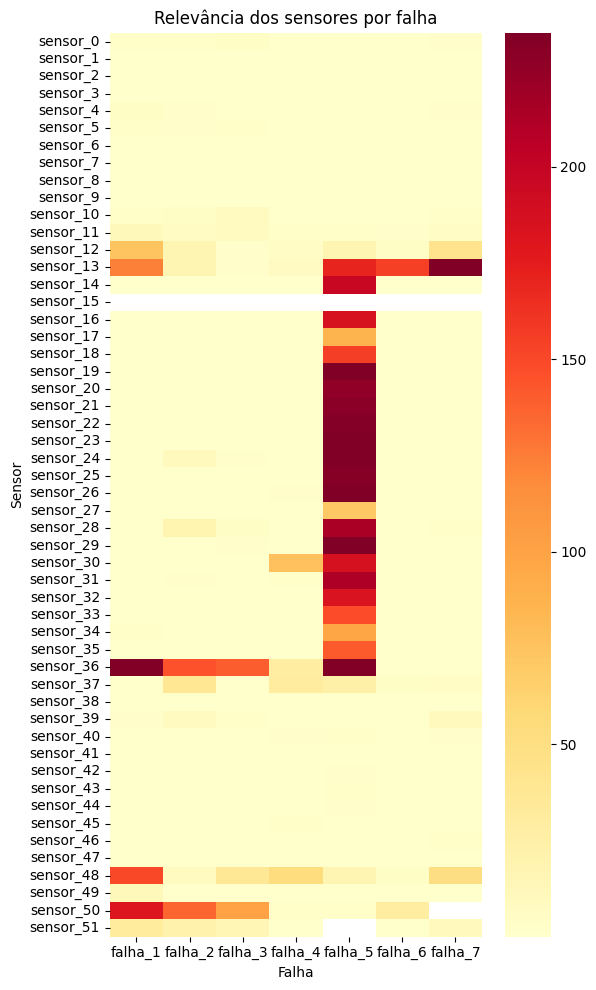

In [27]:
matriz_score = ranking_df.pivot(
    index="sensor",
    columns="falha",
    values="score"
)

ordem_sensores = sorted(
    matriz_score.index,
    key=lambda sensor: int(sensor.split("_")[1])
)

ordem_falhas = sorted(
    matriz_score.columns,
    key=lambda falha: int(falha.split("_")[1])
)

matriz_score = matriz_score.loc[
    ordem_sensores,
    ordem_falhas
]

fig, ax = plt.subplots(figsize=(6, 10))

sns.heatmap(
    matriz_score,
    cmap="YlOrRd",
    ax=ax
)

ax.set_title("Relevância dos sensores por falha")
ax.set_xlabel("Falha")
ax.set_ylabel("Sensor")

plt.tight_layout()
plt.show()

/tmp/ipykernel_11913/2393656317.py:124: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(resumir_sensor)


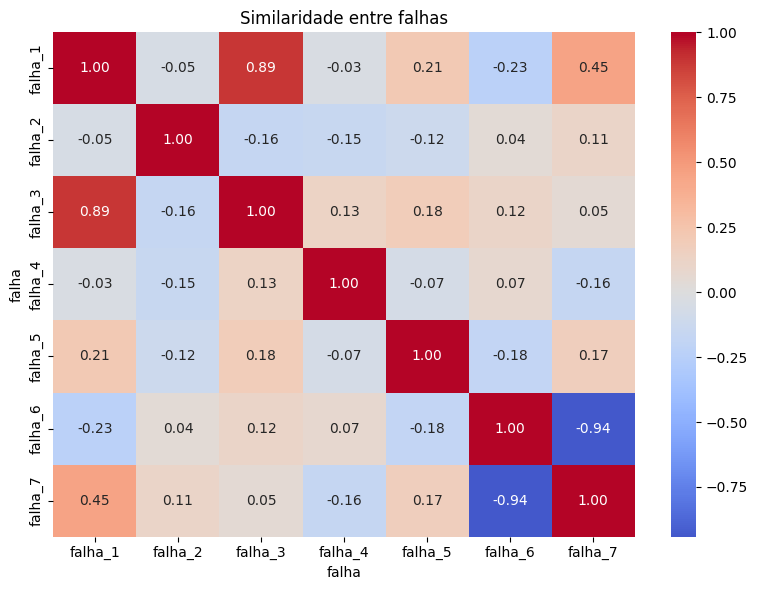

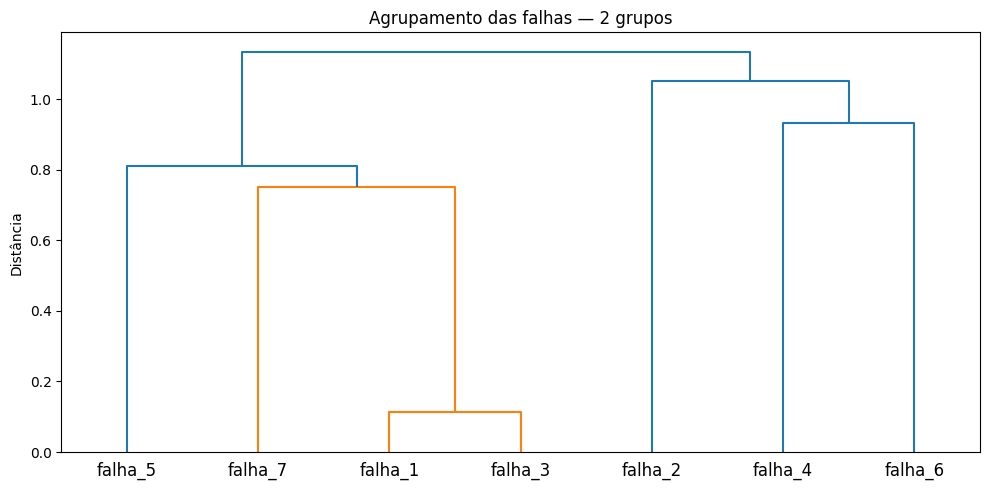

Grupos encontrados:
Tipo 1: falha_1, falha_3, falha_5, falha_7
Tipo 2: falha_2, falha_4, falha_6

Sensores mais relevantes — Tipo 1


,tipo_falha,sensor,falhas_no_grupo,falhas_significativas,frequencia_significativa,efeito_medio_abs,score_medio,consistencia_direcao,direcao_predominante,score_ranking
0,1,sensor_36,4,3,75.0%,0.712,151.529,1.00,aumentou,113.646
1,1,sensor_13,4,4,100.0%,0.718,132.148,0.50,diminuiu,99.111
2,1,sensor_48,4,4,100.0%,0.605,63.806,0.50,diminuiu,47.854
3,1,sensor_50,4,3,75.0%,0.625,94.513,0.33,diminuiu,47.257
4,1,sensor_12,4,4,100.0%,0.461,33.793,1.00,diminuiu,33.793
5,1,sensor_29,4,2,50.0%,0.306,58.997,1.00,aumentou,29.499
6,1,sensor_21,4,2,50.0%,0.275,57.514,1.00,aumentou,28.757
7,1,sensor_28,4,3,75.0%,0.359,54.947,0.33,aumentou,27.474
8,1,sensor_14,4,2,50.0%,0.279,49.337,1.00,aumentou,24.669
9,1,sensor_30,4,2,50.0%,0.266,46.517,1.00,aumentou,23.259



Sensores mais relevantes — Tipo 2


,tipo_falha,sensor,falhas_no_grupo,falhas_significativas,frequencia_significativa,efeito_medio_abs,score_medio,consistencia_direcao,direcao_predominante,score_ranking
0,2,sensor_50,3,3,100.0%,0.519,55.959,1.00,diminuiu,55.959
1,2,sensor_13,3,3,100.0%,0.536,59.892,0.33,aumentou,39.928
2,2,sensor_36,3,3,100.0%,0.478,58.161,0.33,diminuiu,38.774
3,2,sensor_37,3,3,100.0%,0.436,24.356,1.00,aumentou,24.356
4,2,sensor_30,3,2,66.7%,0.276,25.640,1.00,diminuiu,17.093
5,2,sensor_48,3,3,100.0%,0.402,21.971,0.33,aumentou,14.647
6,2,sensor_51,3,3,100.0%,0.237,7.430,1.00,diminuiu,7.430
7,2,sensor_12,3,3,100.0%,0.316,8.721,0.33,diminuiu,5.814
8,2,sensor_11,3,3,100.0%,0.228,3.411,1.00,diminuiu,3.411
9,2,sensor_28,3,2,66.7%,0.193,6.474,0.00,aumentou,2.158


In [28]:
analise_falhas = agrupar_falhas_e_rankear(
    ranking_df,
    max_clusters=4,
    top_n=10
)

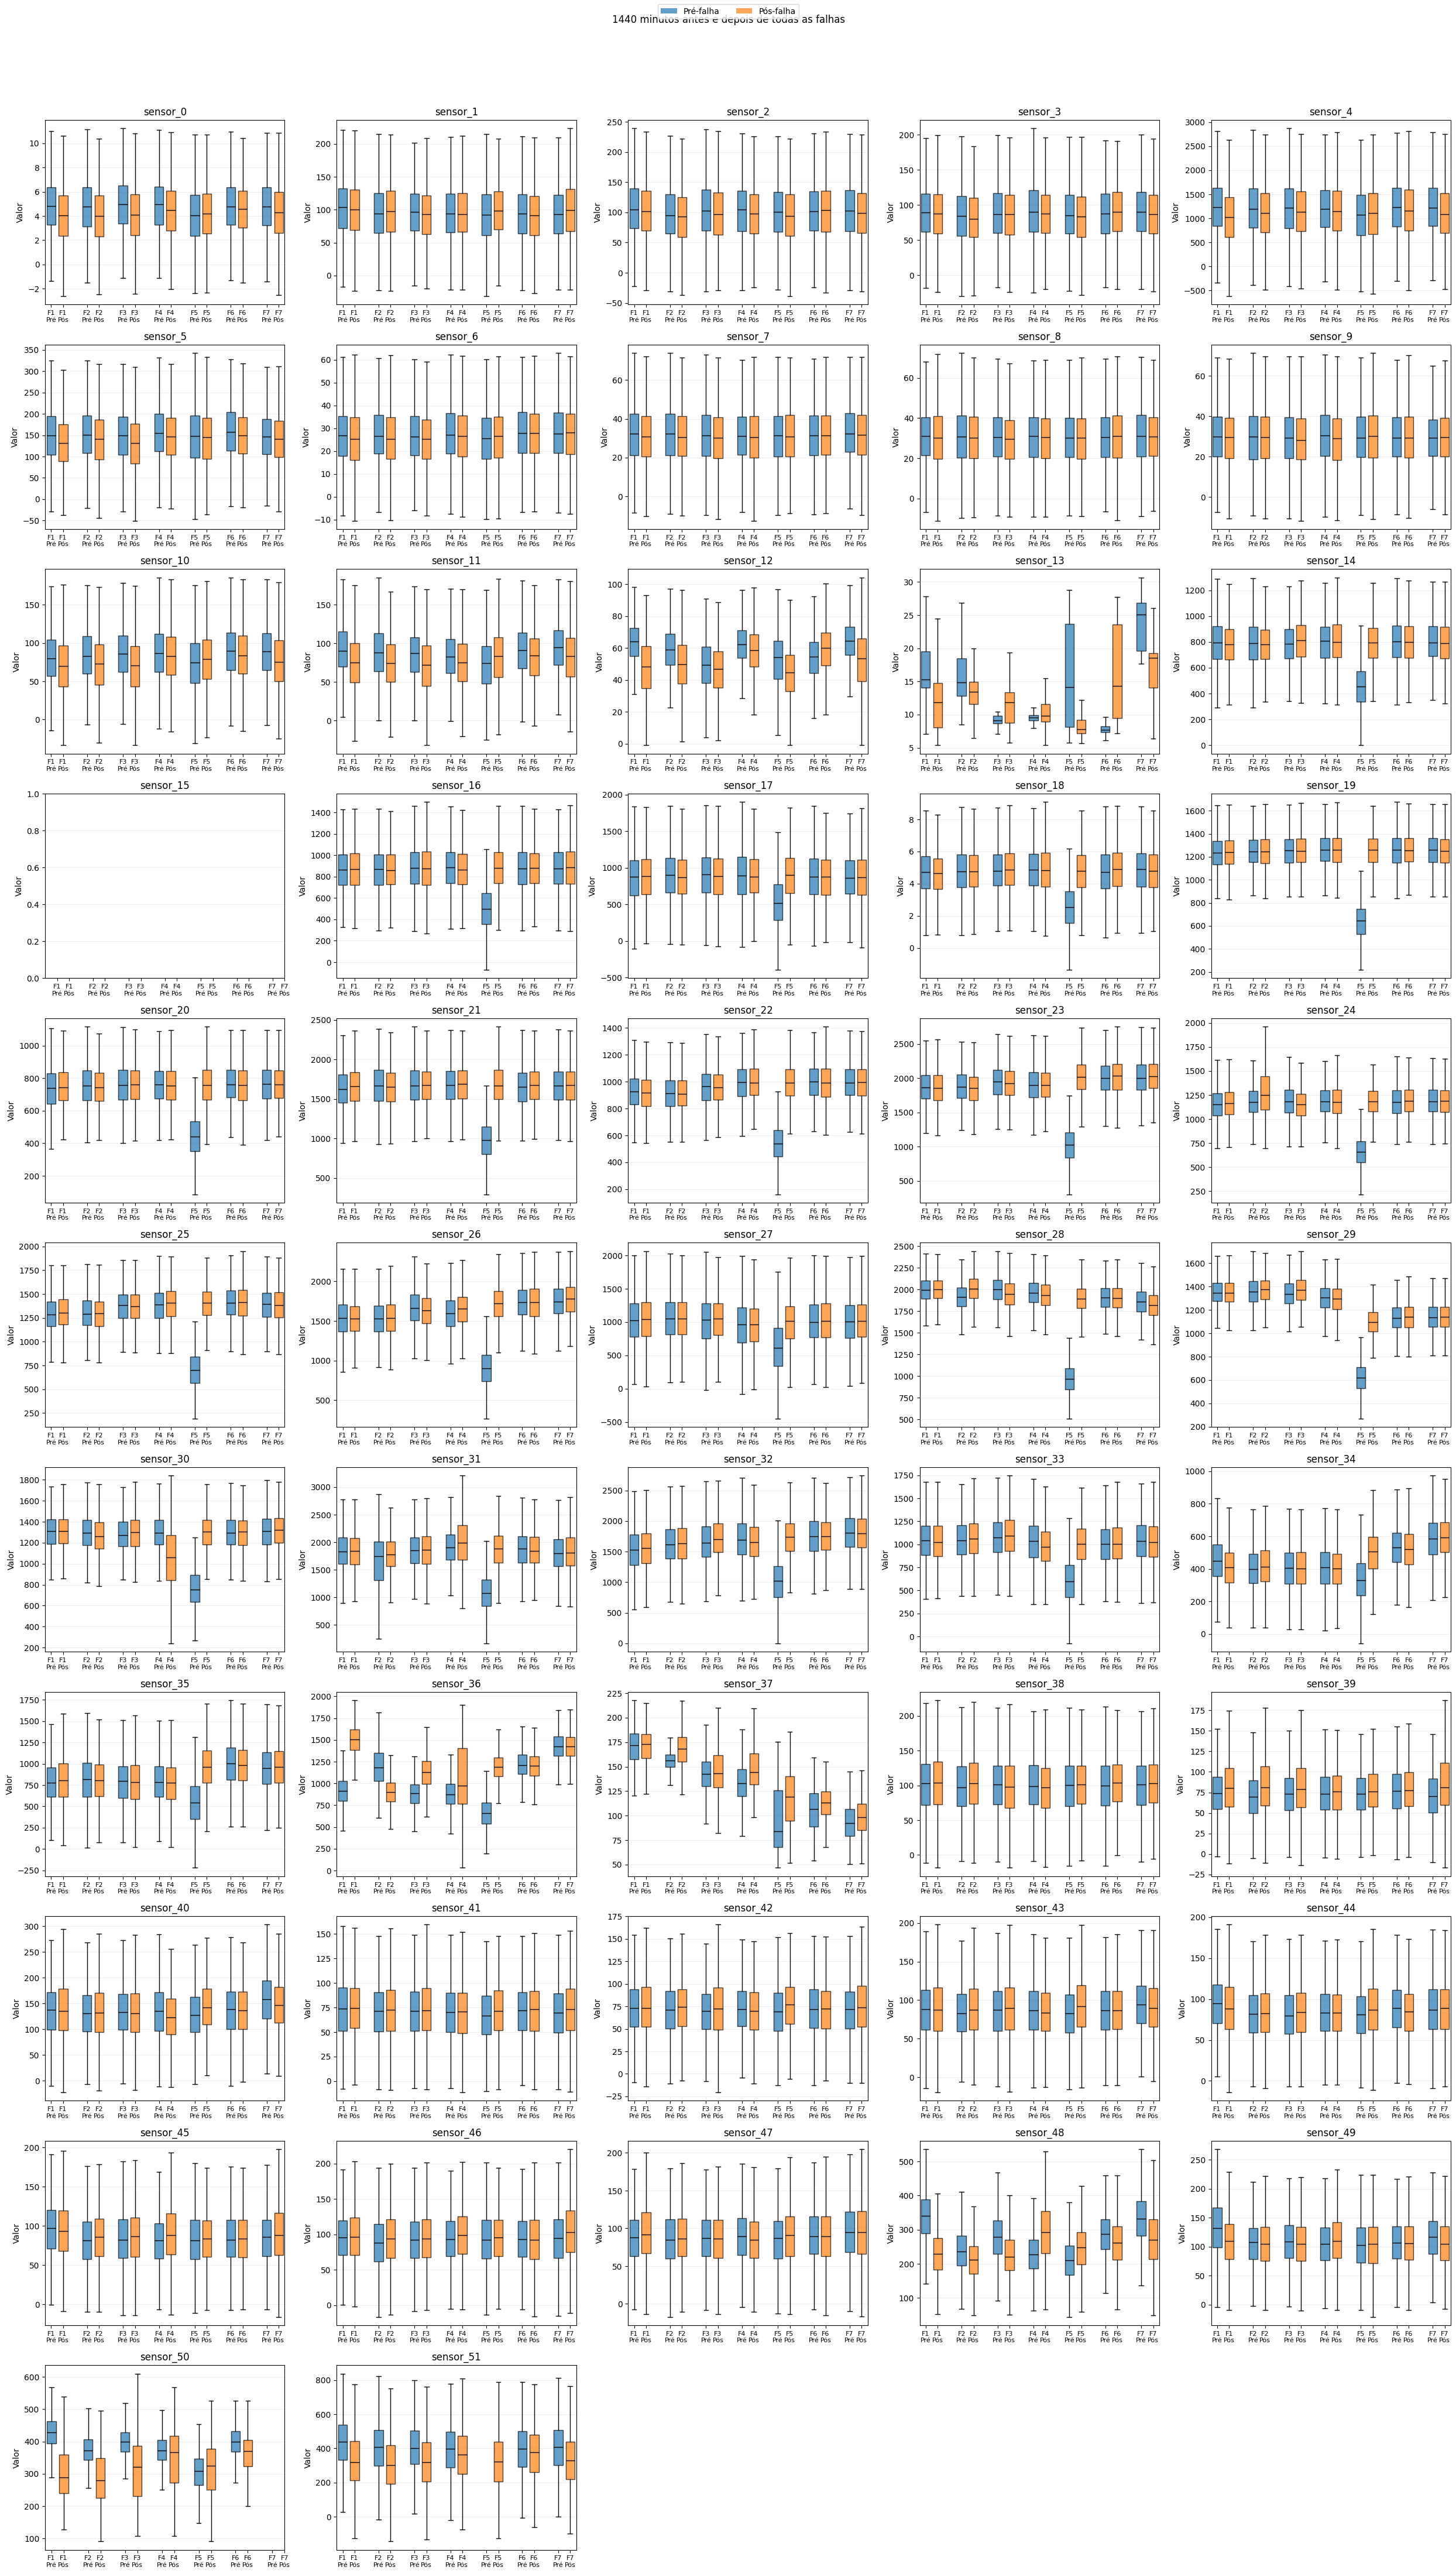

In [29]:
plotar_boxplots_todas_falhas(
    eda_df,
    minutos=PERIODO_ANALISE,
)

Para a análise de 1 dia de antecedência podemos observar que para a **falha 5**, os sensores que influenciavam ela para 1 hora de antecedência continuam influenciando. Já para as outras falhas, muitos dos sensores que possuíam distribuição de dados diferente já não possuem mais.

## Analisando correlações dos sensores

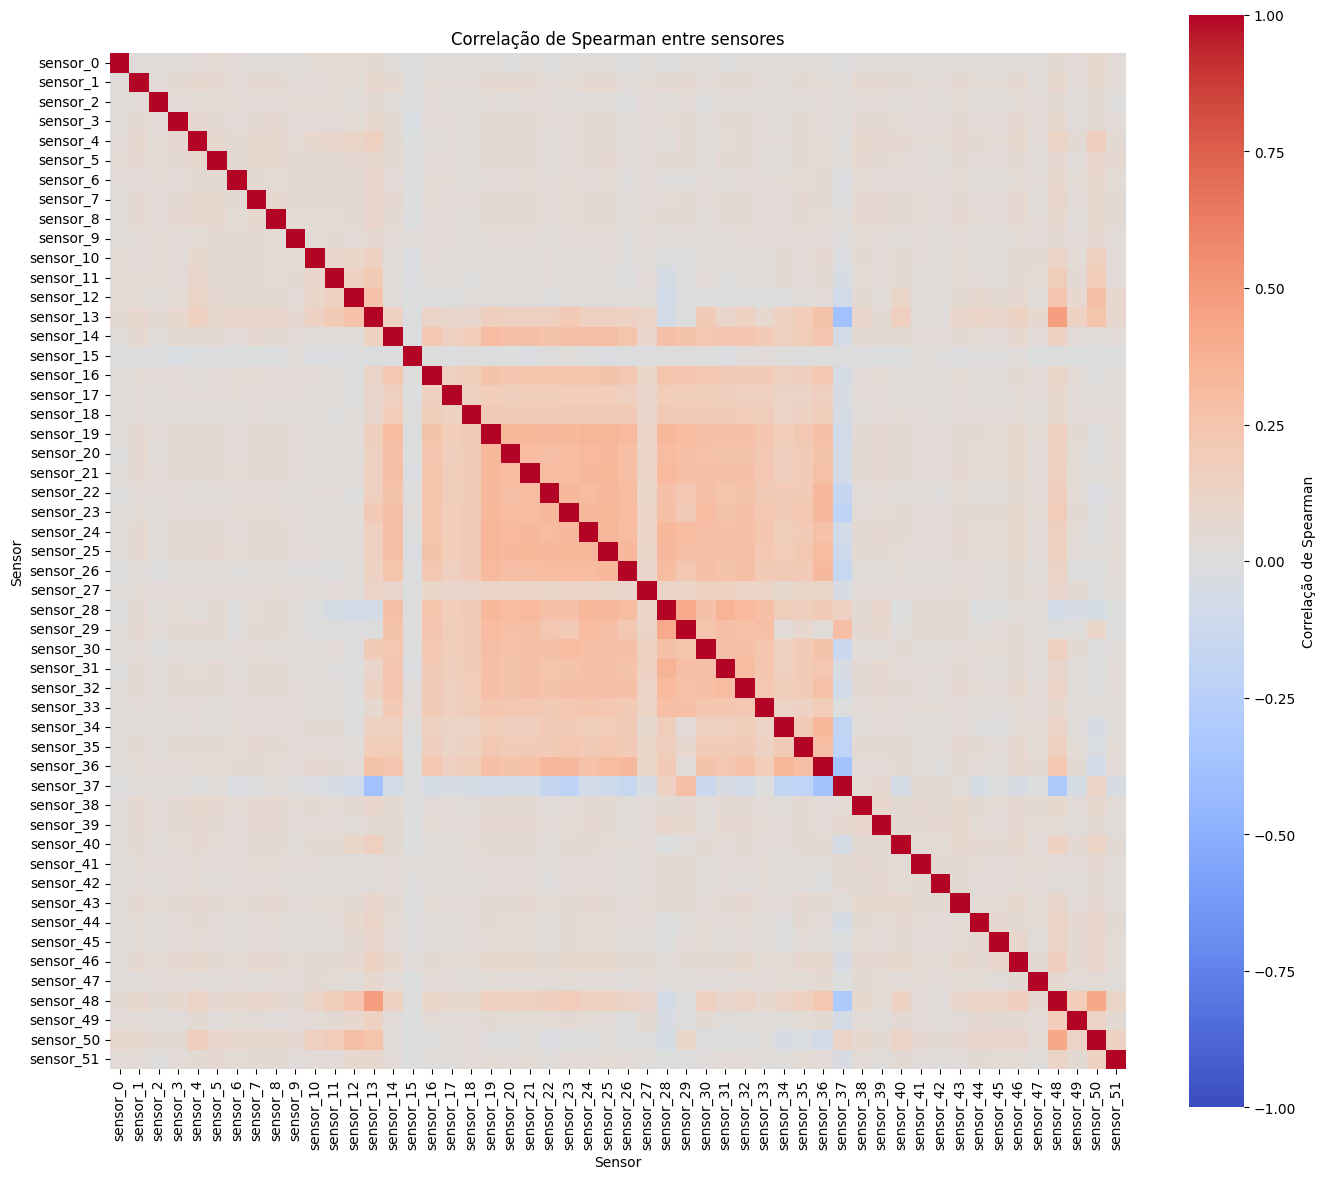

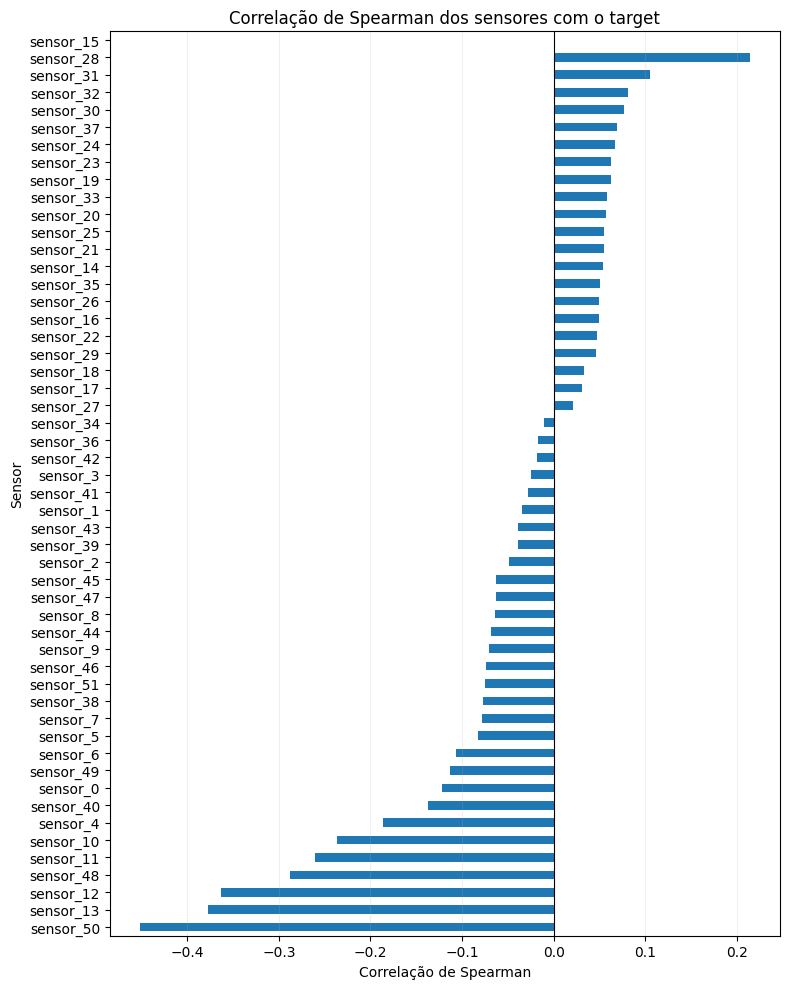

In [30]:
matriz_correlacao, correlacao_target = analisar_correlacoes_spearman(
    eda_df
)

In [31]:
ranking_target = (
    correlacao_target
    .rename("correlacao")
    .to_frame()
    .assign(
        correlacao_absoluta=lambda x: x["correlacao"].abs()
    )
    .sort_values(
        "correlacao_absoluta",
        ascending=False
    )
)

ranking_target.head(10)

,correlacao,correlacao_absoluta
sensor_50,-0.451371,0.451371
sensor_13,-0.377363,0.377363
sensor_12,-0.363512,0.363512
sensor_48,-0.288264,0.288264
sensor_11,-0.260299,0.260299
sensor_10,-0.236572,0.236572
sensor_28,0.213973,0.213973
sensor_4,-0.185807,0.185807
sensor_40,-0.137156,0.137156
sensor_0,-0.121555,0.121555


Agora podemos atualizar o nosso ranking:

<center>

| Ranking | Top sensores tipo de falha 1 | Top sensores tipo de falha 2 | Top sensores por correlação de Spearman com o target |
|:---:|:---:|:---:|:---:|
| 1 | `sensor_13` | `sensor_19` | `sensor_50` |
| 2 | `sensor_12` | `sensor_28` | `sensor_13` |
| 3 | `sensor_50` | `sensor_29` | `sensor_12` |
| 4 | `sensor_11` | `sensor_23` | `sensor_48` |
| 5 | `sensor_10` | `sensor_26` | `sensor_11` |
| 6 | `sensor_37` | `sensor_21` | `sensor_10` |
| 7 | `sensor_51` | `sensor_37` | `sensor_28` |
| 8 | `sensor_48` | `sensor_30` | `sensor_4` |
| 9 | `sensor_5` | `sensor_25` | `sensor_40` |
| 10 | `sensor_0` | `sensor_20` | `sensor_0` |

</center>

Podemos observar que todos os top sensores da correlação de Spearman se parece bastante com os top sensores do tipo de falha 1. Como o tipo de falha 2 representa apenas uma falhas no dataset inteiro, os sensores relacionados a essa falha específica não ficam tão evidentes na correlação.

Fazendo uma intercessão dos sensores da correlação de Spearman com do tipo de falha 1 temos os seguintes sensores:

- `sensor_13`, `sensor_12`, `sensor_50`, `sensor_11`, `sensor_10`, `sensor_48`, `sensor_0`